In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/unsupervised_files/study_hours.csv")

In [ ]:
df

,Unnamed: 0,Study_Hours,Exam_Score
0,0,24.264664,64.657487
1,1,22.357262,72.128936
2,2,22.261474,70.396688
3,3,23.441185,64.278301
4,4,25.824502,71.802608
...,...,...,...
1495,1495,14.107012,78.837862
1496,1496,22.221010,77.099930
1497,1497,19.820106,75.154423
1498,1498,18.835305,76.450343


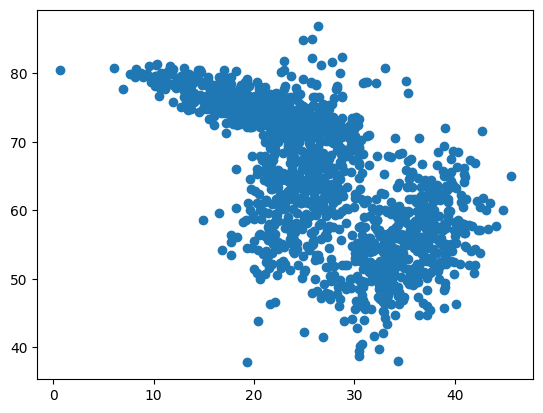

In [ ]:
plt.scatter(df['Study_Hours'],df['Exam_Score'])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["Study_Hours", "Exam_Score"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

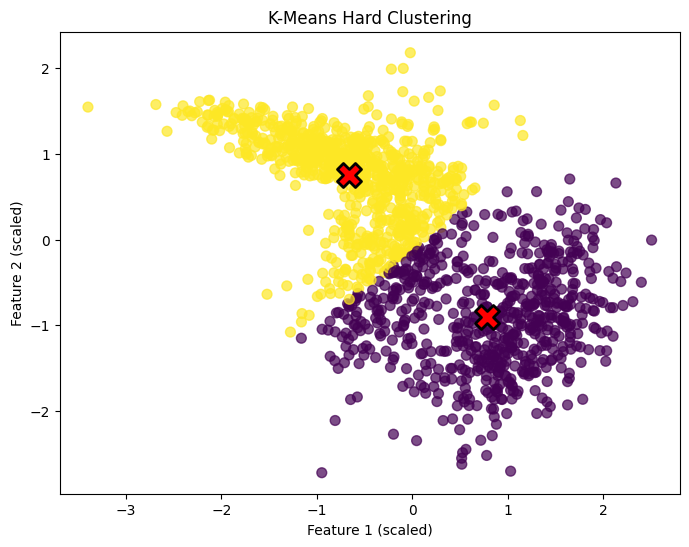

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ---------------------------
# KMeans with 2 clusters
# ---------------------------
kmeans = KMeans(n_clusters=2)
km_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = km_labels

# ---------------------------
# Plot hard KMeans clusters
# ---------------------------
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=km_labels,
    cmap="viridis",
    s=50,
    alpha=0.7
)

# Plot cluster centroids
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:,0], centers[:,1],
    s=300, c="red", marker="X", edgecolor="black", linewidth=2
)

plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("K-Means Hard Clustering")
plt.show()


In [ ]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2)
gmm.fit(X_scaled)

# Hard clustering: assign each point to the component with highest probability
df["cluster"] = gmm.predict(X_scaled)

# Soft clustering probabilities
probs = gmm.predict_proba(X_scaled)
df[["prob_cluster_0", "prob_cluster_1"]] = probs

In [ ]:
df

,Unnamed: 0,Study_Hours,Exam_Score,kmeans_cluster,cluster,prob_cluster_0,prob_cluster_1
0,0,24.264664,64.657487,1,1,0.000030,0.999970
1,1,22.357262,72.128936,1,0,0.872908,0.127092
2,2,22.261474,70.396688,1,0,0.531885,0.468115
3,3,23.441185,64.278301,1,1,0.000005,0.999995
4,4,25.824502,71.802608,1,0,0.812331,0.187669
...,...,...,...,...,...,...,...
1495,1495,14.107012,78.837862,1,0,0.992602,0.007398
1496,1496,22.221010,77.099930,1,0,0.900023,0.099977
1497,1497,19.820106,75.154423,1,0,0.973412,0.026588
1498,1498,18.835305,76.450343,1,0,0.980307,0.019693


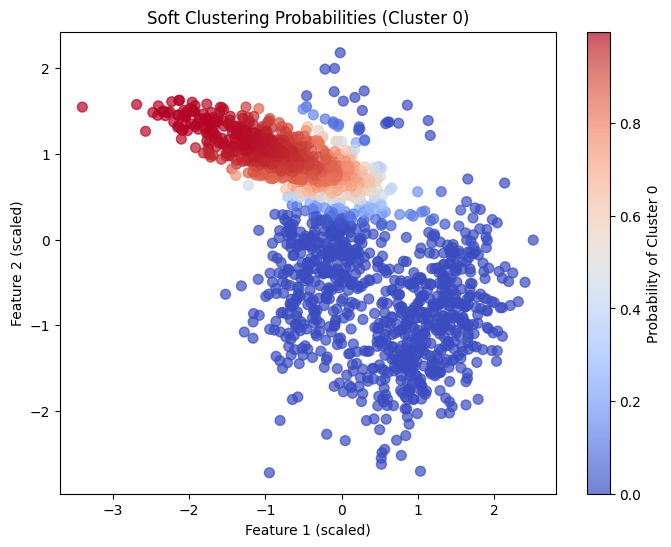

In [ ]:
# -----------------------------
# Plot soft cluster probabilities for cluster 0
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=probs[:,0], cmap='coolwarm', s=50, alpha=0.7)
plt.colorbar(label="Probability of Cluster 0")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("Soft Clustering Probabilities (Cluster 0)")
plt.show()

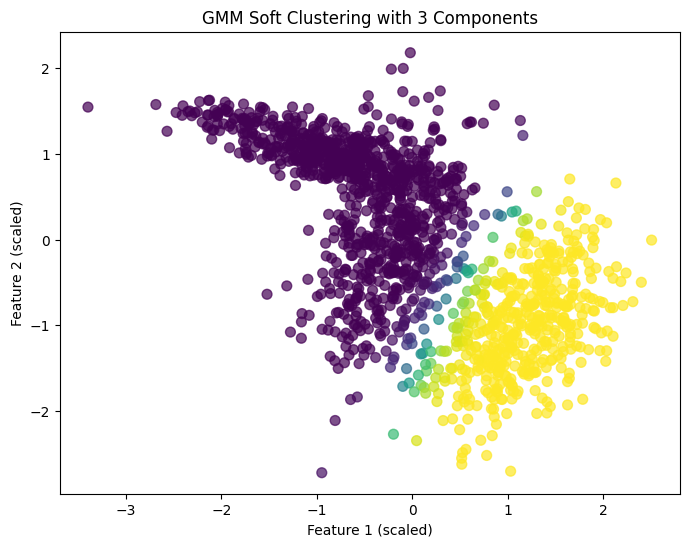

In [ ]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# Hard clustering: assign each point to the component with highest probability
df["cluster"] = gmm.predict(X_scaled)

# Optional: soft clustering probabilities
probs = gmm.predict_proba(X_scaled)
df[["prob_cluster_0", "prob_cluster_1", "prob_cluster_2"]] = probs

# -----------------------------
# Plot hard clusters
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=probs[:,0], cmap='viridis', s=50, alpha=0.7)
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.title("GMM Soft Clustering with 3 Components")
plt.show()